In [8]:
from py_compile import main
import numpy as np
import jax.numpy as jnp
import capytaine as cpt
from capytaine.io.meshio import load_from_meshio
import matplotlib.pyplot as plt
from scipy.optimize import brute
import pygmsh
import gmsh
from scipy.linalg import block_diag
import xarray as xr
import jax
import os
 
# Custom libraries
import wecopttool as wot

# Import examples variables
#from hydro_inputs import waves, freq, platform, flap1, flap2

## set colorblind-friendly colormap for plots
plt.style.use('tableau-colorblind10')

import logging
logging.getLogger().setLevel(logging.INFO)

In [9]:
wavefreq = 1/8 # Hz
f1 = wavefreq
nfreq = 10

freq = wot.frequency(f1, nfreq, False) # False -> no zero frequency

amplitude = 0.01/2 # m
phase = 0 # degrees
wavedir = 0 # degrees

waves = wot.waves.regular_wave(f1, nfreq, wavefreq, amplitude, phase, wavedir)

INFO:capytaine.io.meshio:Stored 312 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_29"), lid_mesh=None, dofs={}, center_of_mass=[ 0.    0.   -0.36], name="flap").
INFO:capytaine.bodies.bodies:Clipping flap with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_29 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.


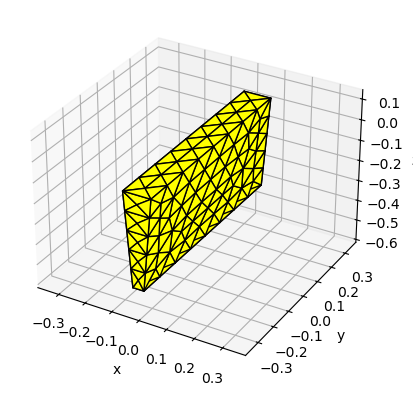

In [42]:
# platform is a rectangle with cg at -0.46 and 1.44 m long, 0.76 m wide
flapThicknessBottom = 0.04
flapThicknessTop = 0.1
flapWidth = 0.76
flapHeight = 0.45
cg_z = -.01 - (flapHeight/3)*((flapThicknessTop + 2*flapThicknessBottom)/(flapThicknessTop + flapThicknessBottom))
flapCG = [0, 0, -0.36] # from water surface/origin
hingePoint = [0, 0, -0.5]

with pygmsh.geo.Geometry() as geom:
    flap = geom.add_polygon(
            [[-flapThicknessBottom/2, -flapWidth/2, -0.46],
            [flapThicknessBottom/2, -flapWidth/2, -0.46],
            [flapThicknessTop/2, -flapWidth/2, -0.46+flapHeight],
            [-flapThicknessTop/2, -flapWidth/2, -0.46+flapHeight]],mesh_size=0.1)
    geom.extrude(flap,[0,flapWidth,0])
    flapMesh = geom.generate_mesh()

# define the floating body
flap_hinge = cpt.FloatingBody(mesh=flapMesh, name=f'flap', center_of_mass=flapCG)
flap_hinge.rotation_center = hingePoint # define rotation about cg and M4E will handle transformaiton
#flap_hinge.add_translation_dof(name='Surge')
#flap_hinge.add_translation_dof(name='Heave')
axisHinge = cpt.Axis(vector=(0, 1, 0), point=hingePoint)
flap_hinge.add_rotation_dof(axis=axisHinge, name='Pitch_hinge')
flap_hinge = flap_hinge.immersed_part()
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([1.19 + 0.5*(.05*.76*.56)*1000*(0.14)**2]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(flap_hinge.dofs),
                                    'radiating_dof': list(flap_hinge.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
flap_hinge.inertia_matrix = rigid_inertia_matrix_xr
flap_hinge.hydrostatic_stiffness = flap_hinge.compute_hydrostatic_stiffness(rho=1025)

flap_hinge.show_matplotlib()
#flap.show()


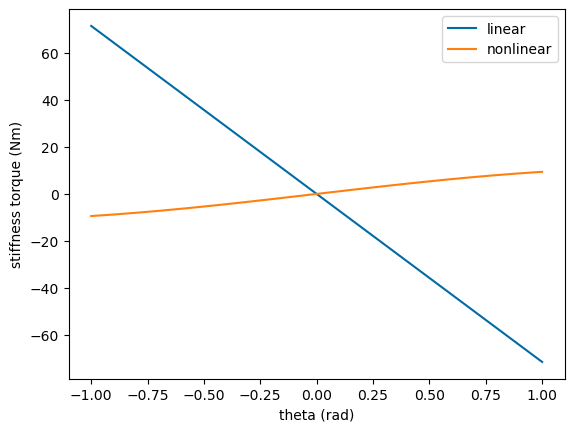

In [ ]:
# check hydrostatic stiffness
rho = 1025
V = flap_hinge.volume
m = 0.5*(.05*.76*.56)*1000
m = rho*V
g = 9.81
cg_z = flapCG[2]
cb_z = flap_hinge.center_of_buoyancy[2]
theta_vec = np.linspace(-1, 1, 20)
hs_lin = np.zeros_like(theta_vec)
hs_nl = np.zeros_like(theta_vec)

for i, theta in enumerate(theta_vec):
    hs_lin[i] = -np.squeeze(flap_hinge.hydrostatic_stiffness*theta)
    hs_nl[i] = np.squeeze(-rho*V*g*cb_z*np.sin(theta) + m*g*cg_z*np.sin(theta))


plt.figure()
plt.plot(theta_vec, hs_lin, label='linear')
plt.plot(theta_vec, hs_nl, label='nonlinear')
plt.xlabel('theta (rad)')
plt.ylabel('stiffness torque (Nm)')
plt.legend()

In [11]:
#%% Load or run BEM
fname = 'bem_oneFlap_hinge.nc'
if os.path.exists(fname):
    bem_data = wot.read_netcdf(fname)
else:
    bem_data = wot.run_bem(flap_hinge, freq, wave_dirs=0)
    bem_data['radiating_dof'] = bem_data['radiating_dof'].astype(str)
    bem_data['influenced_dof'] = bem_data['influenced_dof'].astype(str)
    wot.write_netcdf(fname, bem_data)

INFO:capytaine.green_functions.delhommeau:Loading tabulation from C:\Users\jtgrasb\AppData\Local\capytaine\Cache\2.3.1\tabulation_float64_scaled_nemoh3_676_100.0_372_-251.0_1001.npz


[15:07:55] WARNING  center_of_mass already defined as [ 0.    0.   -0.36].

           WARNING  rotation_center already defined as [0, 0, -0.5].

INFO:capytaine.bodies.bodies:Clipping copy_of_flap with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_12 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.


Output()

INFO:capytaine.bem.solver:Solve DiffractionProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=0.785, water_depth=inf, wave_direction=0.000, rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=0.785, water_depth=inf, radiating_dof='Pitch_hinge', rho=1025.0).
INFO:capytaine.bem.solver:Solve DiffractionProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=1.571, water_depth=inf, wave_direction=0.000, rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=1.571, water_depth=inf, radiating_dof='Pitch_hinge', rho=1025.0).
INFO:capytaine.bem.solver:Solve DiffractionProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=2.356, water_depth=inf, wave_direction=0.000, rho=1025.0).


INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=2.356, water_depth=inf, radiating_dof='Pitch_hinge', rho=1025.0).
INFO:capytaine.bem.solver:Solve DiffractionProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=3.142, water_depth=inf, wave_direction=0.000, rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=3.142, water_depth=inf, radiating_dof='Pitch_hinge', rho=1025.0).
INFO:capytaine.bem.solver:Solve DiffractionProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=3.927, water_depth=inf, wave_direction=0.000, rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=3.927, water_depth=inf, radiating_dof='Pitch_hinge', rho=1025.0).
INFO:capytaine.bem.solver:Solve DiffractionProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=4.712, water_depth=inf, 

INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=4.712, water_depth=inf, radiating_dof='Pitch_hinge', rho=1025.0).
INFO:capytaine.bem.solver:Solve DiffractionProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=5.498, water_depth=inf, wave_direction=0.000, rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=5.498, water_depth=inf, radiating_dof='Pitch_hinge', rho=1025.0).
INFO:capytaine.bem.solver:Solve DiffractionProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=6.283, water_depth=inf, wave_direction=0.000, rho=1025.0).


INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=6.283, water_depth=inf, radiating_dof='Pitch_hinge', rho=1025.0).
INFO:capytaine.bem.solver:Solve DiffractionProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=7.069, water_depth=inf, wave_direction=0.000, rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=7.069, water_depth=inf, radiating_dof='Pitch_hinge', rho=1025.0).
INFO:capytaine.bem.solver:Solve DiffractionProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=7.854, water_depth=inf, wave_direction=0.000, rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap_immersed"), omega=7.854, water_depth=inf, radiating_dof='Pitch_hinge', rho=1025.0).


INFO:capytaine.bem.solver:Solver timer summary:
                     total  nb_calls      mean
task                                          
Solve total       0.444502        20  0.022225
  Green function  0.235009        20  0.011750
  Linear solver   0.136232        20  0.006812


In [12]:
print(bem_data['added_mass'])

<xarray.DataArray 'added_mass' (omega: 10, radiating_dof: 1, influenced_dof: 1)> Size: 80B
array([[[14.8382191 ]],

       [[15.29316739]],

       [[16.24146846]],

       [[17.97671974]],

       [[20.6546702 ]],

       [[22.73407012]],

       [[18.72604885]],

       [[ 9.89815583]],

       [[ 4.54060809]],

       [[ 2.6474253 ]]])
Coordinates:
  * omega           (omega) float64 80B 0.7854 1.571 2.356 ... 6.283 7.069 7.854
  * radiating_dof   (radiating_dof) <U11 44B 'Pitch_hinge'
  * influenced_dof  (influenced_dof) <U11 44B 'Pitch_hinge'
    g               float64 8B 9.81
    rho             float64 8B 1.025e+03
    body_name       <U21 84B 'copy_of_flap_immersed'
    water_depth     float64 8B inf
    forward_speed   float64 8B 0.0
    freq            (omega) float64 80B 0.125 0.25 0.375 0.5 ... 1.0 1.125 1.25
    period          (omega) float64 80B 8.0 4.0 2.667 2.0 ... 1.0 0.8889 0.8
Attributes:
    long_name:  Added mass


INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.59e-02, nan, 0.00e+00]
INFO:wecopttool.core:Optimization terminated successfully    (Exit mode 0)


Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.0
            Iterations: 1
            Function evaluations: 2
            Gradient evaluations: 1


c:\Users\jtgrasb\AppData\Local\anaconda3\envs\wot_dev\Lib\site-packages\wecopttool\core.py:967: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'omega' ('omega',) The recommendation is to set join explicitly for this case.
  results_fd = xr.merge([fd_state, fd_forces, wave])
c:\Users\jtgrasb\AppData\Local\anaconda3\envs\wot_dev\Lib\site-packages\wecopttool\core.py:967: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  results_fd 

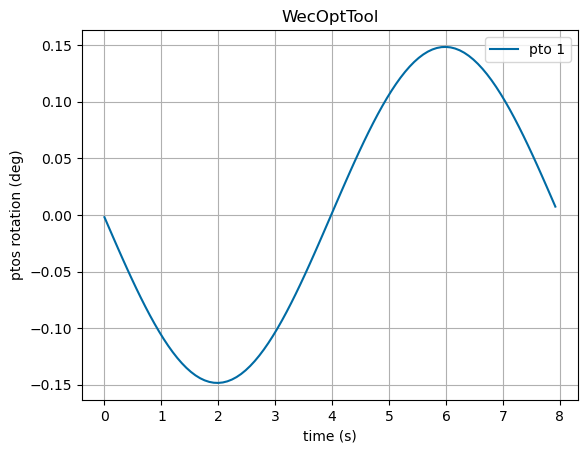

In [13]:

f_add = {} #{'mooring': f_mooring}

#%% Define and solve the WOT object
wec = wot.WEC.from_bem(
    bem_data,
    constraints=None,
    friction=None,
    f_add=f_add,
)

# Objective function
obj_fun = lambda wec, x_wec, x_opt, waves : 0
nstate_opt = 0

# Solve
scale_x_wec = 1e1
scale_x_opt = 1e-3
scale_obj = 1e-2

results = wec.solve(
    waves,
    obj_fun,
    nstate_opt,
    scale_x_wec=scale_x_wec,
    scale_x_opt=scale_x_opt,
    scale_obj=scale_obj,
)

#%% Plot results
nsubsteps = 5
wec_fdom, wec_tdom = wec.post_process(wec, results, waves, nsubsteps=nsubsteps)
# wec_tdom['wave_elev'].plot()

# plt.figure()
# plt.plot(wec_tdom['time'],wec_tdom.pos[0,0,:])
# plt.plot(wec_tdom['time'],wec_tdom.pos[0,1,:])
# plt.plot(wec_tdom['time'],wec_tdom.pos[0,2,:]*180/np.pi)
# plt.xlabel('time (s)')
# plt.ylabel('platform position (m or deg)')
# plt.legend(['surge','heave','pitch'])
# plt.grid()


plt.figure()
plt.plot(wec_tdom['time'],wec_tdom.pos[0,0,:]*180/np.pi)
#plt.plot(wec_tdom['time'],wec_tdom.pos[0,0,:]*180/np.pi)
plt.xlabel('time (s)')
plt.ylabel('ptos rotation (deg)')
plt.legend(['pto 1'])
plt.title('WecOptTool')
plt.grid()
plt.show()